In [1]:
import importlib.util
if importlib.util.find_spec('empylib') is None:
    !pip install git+https://github.com/PanxoPanza/empylib.git

# Manejo térmico radiativo en edificaciones

## Introducción

Los edificios representan alrededor del **30% de la demanda energética global** (IEA, *Energy Efficiency 2025*). Considerando solo la operación de edificios, la IEA reporta cerca del **26% de las emisiones globales relacionadas con energía** (IEA, *Buildings*).


<img src="./images/consumo_vivienda_chile.jpg" width="600" align=center>

<center><small><b>Figura 1.</b> Consumo energético en vivienda según uso (El Mercurio, "del carbón al sol: El mapa energético de chile").</small></center>

El enfriamiento de espacios es uno de los usos de energía de mayor crecimiento en edificios. La IEA (*The Future of Cooling*, 2018) indica que el aire acondicionado y los ventiladores representan cerca del **20% de la electricidad usada en edificios** (aproximadamente 10% de la electricidad global) y que, sin políticas de eficiencia, la demanda energética para enfriamiento de espacios podría **más que triplicarse hacia 2050**.


*¿Por qué crece tanto la demanda de enfriamiento?*

- Aumento de ingresos y acceso a equipos de climatización en países en desarrollo.
- Urbanización acelerada e islas de calor urbanas.
- Cambio climático: veranos más calurosos y períodos de calor más extremos.
- Diseño de edificios con gran superficie vidriada sin control solar adecuado.

*¿Qué herramientas tiene la ingeniería para reducir la carga térmica de un edificio sin aumentar su consumo eléctrico?*

La respuesta está, en gran medida, en la **envolvente del edificio**: muros, ventanas y techo son la interfaz entre el interior y el exterior. Controlar cómo esa envolvente interactúa con la radiación solar y la radiación térmica es la clave.

<img src="./images/passive_solar_management.png" width="700" align=center>

<center><small><b>Figura 2.</b> Estrategias de manejo térmico en la envolvente de edificaciones (Kalogirou, 2014).</small></center>

En este capítulo nos enfocaremos en cómo la envolvente del edificio afecta las cargas de calefacción, enfriamiento e iluminación.

## Estrategias tradicionales no selectivas

La estrategia de manejo solar en edificaciones puede ser definida anticipadamente en el diseño arquitectónico, con soluciones de bajo costo, bajo nivel de mantenimiento y larga vida útil. Sin embargo, no son fácilmente modificables una vez construidas y, en la mayoría de los casos, no son selectivas (es decir, afectan por igual a la radiación solar y a la radiación térmica).

### Masa térmica y desfase térmico

La **masa térmica** es la capacidad de un material de construcción para almacenar calor. Se expresa como el producto $\rho \cdot c_p$ [J/m³·K]:

<img src="./images/masa_termica_tabla.png" width="500" align=center>

<center><small><b>Figura 3.</b> Propiedades térmicas en materiales de construcción típicos.</small></center>

El **desfase térmico** describe el retraso con que el calor almacenado es liberado. Un muro de alta masa térmica puede desplazar el peak de temperatura interior varias horas respecto al peak solar exterior:

<img src="./images/thermal_lag.png" width="650" align=center>

<center><small><b>Figura 4.</b> Desfase térmico: la masa térmica amortigua y desplaza el peak de temperatura interior respecto al exterior.</small></center>

Un diseño bien calibrado de masa térmica reduce la amplitud de la oscilación de temperatura interior y puede eliminar completamente la necesidad de climatización en climas templados.

### Muro de Trombe

El **muro de Trombe** combina masa térmica con captación solar activa. Un muro de concreto pintado de negro oscuro se separa de una superficie de vidrio, formando una cámara de aire que actúa como colector solar.

<img src="./images/trombe_wall.png" width="650" align=center>

<center><small><b>Figura 5.</b> Esquema de operación del muro de Trombe en modo calefacción (invierno) y ventilación (verano).</small></center>



- **Invierno:** el calor almacenado en el concreto se libera por convección natural hacia el interior.
- **Verano:** persianas externas bloquean la radiación; aperturas superiores expulsan el aire caliente.
- **Orientación:** hacia el norte en el hemisferio sur (hacia el sur en el hemisferio norte).

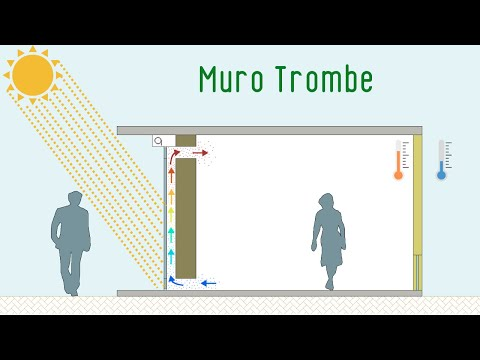

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo('fwIdRKwiOD4', width=700, height=400)

### Orientación y aleros

La orientación de ventanas al norte (hemisferio sur) maximiza la captación solar en invierno. Los **aleros** sobre las ventanas permiten un control estacional natural: bloquean el sol de verano (ángulo solar alto) y permiten el sol de invierno (ángulo solar bajo).

<img src="./images/overhangs.png" width="400" align=center>

<center><small><b>Figura 6.</b> Configuraciones del alero para (a) zonas alejadas de los polos que requieren bloqueo solar en verano (ángulo solar alto), (b) zonas frias cercanas al polo que requieren maximizar captación en invierno (ángulo bajo).</small></center>

## Fundamentos de tecnologías de manejo radiativo

Para entender las estrategias de control térmico en edificaciones, es clave distinguir los actores participantes

| Tipo | Fuente aproximada | Rango espectral dominante | ¿Qué controlar? |
|:---:|:---:|:---:|:---:|
| Radiación solar | ~5800 K (sol) | 0.3 – 2.5 μm (UV, vis, NIR) | Ganancia solar |
| Radiación térmica edificio | ~300 K (paredes, personas) | 5 – 30 μm (mid-IR) | Pérdidas en invierno / emisión en verano |
| Radiación térmica alrededores | ~300 K | 5 – 30 μm (mid-IR) | Ganancia por radiación difusa |
| Ventana atmosférica | N/A |  8 – 13 μm (mid-IR) | Disipación radiativa hacia el universo |

In [3]:
%%capture radiative_spectra

import empylib.ref_spectra as rf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

lam = np.logspace(np.log10(0.25),np.log10(100),1000) # espectro de longitudes de onda
Tbb = 300                                           # temperatura de cuerpo negro

T_atm = rf.T_atmosphere_hemi(lam, 0)     # Transmitancia atmosférica
Gsun = rf.AM15(lam)                      # GHI solar AM1.5
Ebb = np.pi*rf.Bplanck(lam,Tbb)          # Poder de emisión espectral hemisférico de un cuerpo negro

fig, ax1 = plt.subplots(figsize=(12,4))
ax2=ax1.twinx()                          # segundo eje para unidades de radiación espectral
ax1.fill_between(lam,Gsun,label='Irradiancia solar (AM 1.5)', alpha=0.35, color='orange')
ax1.fill_between(lam,Ebb*10,label=r'Irradiancia cuerpo a 300 K ($\times 10)$', alpha=0.3, color='crimson')
ax2.fill_between(lam,T_atm*100, label = r'Transmitancia atmosférica', alpha=0.18, color='steelblue')

ax1.set_ylim(bottom = 0)
ax1.set_xlabel('Longitud de onda, $\mu$m')
ax1.set_xscale('log')
ax1.set_xticks([0.3,0.4,0.75,1.4,3,8,15,30, 50, 100])
ax1.set_ylabel('Irradiancia espectral (W/m$^2$-$\mu$m)')
ax2.set_ylabel('Transmitancia (%)')
ax2.set_xlim(0.25,30)
ax2.set_ylim(bottom = 0)

ax1.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.16g}'.format(y)))

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='lower center',
    bbox_to_anchor=(0, 1.02, 1, 0.2),  # outside, top, full width
    # mode='expand',                      # spread left-center-right
    ncol=3,
    frameon=False,
    borderaxespad=0
)

# # Anotación ventana atmosférica
ax2.annotate('Ventana\natmosférica\n(8–13 μm)', xy=(10.5, 45), fontsize=9,
             ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.6))

plt.show()

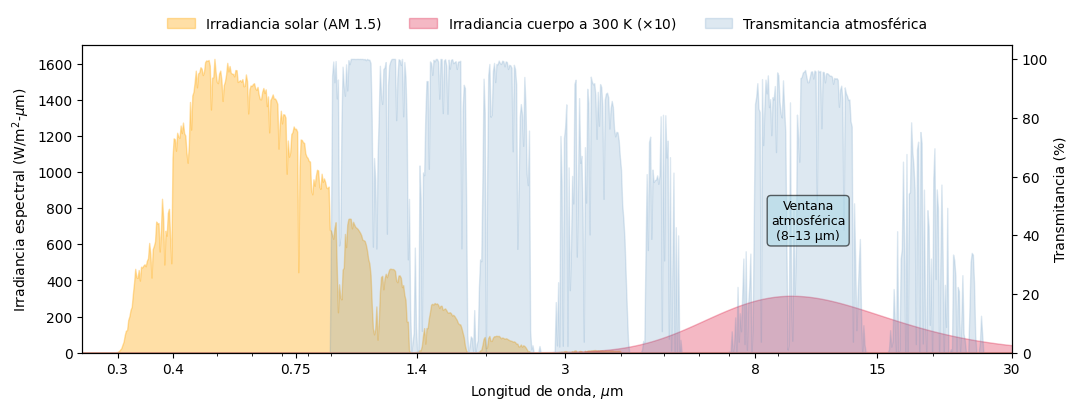

In [4]:
radiative_spectra.show()

Como muestra la figura controlar la ganancia solar (UV + NIR) y controlar la emisión IR térmica son objetivos *distintos* que requieren propiedades ópticas distintas. Un material que bloquea el NIR solar no necesariamente refleja el IR térmico de 10 μm, y viceversa.

Aproximando el espectro solar terrestre con el espectro de referencia AM1.5 (ASTM G173/NREL), la energía solar que llega a la superficie se reparte, como orden de magnitud, en:
- **3%** radiación ultravioleta (UV, $\lambda < 0.38$ μm)
- **44%** luz visible ($\lambda \in [0.38, 0.78]$ μm)
- **53%** infrarrojo cercano (NIR, $\lambda \in [0.78, 2.5]$ μm)

>**Nota:** La mayor parte del calor ganado por radiación solar en un recinto proviene del **NIR**, no del UV.


La atmósfera terrestre es **casi transparente** en el rango $\lambda \in [8, 13]$ μm. Esto tiene dos consecuencias importantes:

1. Los edificios pierden calor por radiación en este rango (noches frías).
2. Materiales diseñados para emitir en esta banda pueden **enfriarse por debajo de la temperatura ambiente**, incluso bajo el sol.

## Ventanas y control solar

Las ventanas son el punto de mayor intercambio radiativo de la envolvente. Un vidrio simple claro tiene alta transmitancia solar, típicamente $T_\mathrm{sol}$ del orden de 0.75–0.86 según espesor y producto; para estimaciones de primer orden usaremos $T_\mathrm{sol} \approx 0.86$. Esto genera ganancias de calor no deseadas en verano y pérdidas en invierno.


Los **recubrimientos y filmes de control solar** modifican la transmitancia espectral del vidrio para reducir estas ganancias y pérdidas de forma selectiva.

### Métricas de desempeño

Para comparar tecnologías de control solar, se usan métricas estandarizadas que resumen el desempeño espectral en un solo número. Las más importantes son:

- **Transmitancia lumínica** ($T_\mathrm{lum}$): fracción de la luz visible que atraviesa el material, ponderada por la sensibilidad del ojo humano.

    \begin{equation*}
    T_\mathrm{lum} = \frac{\int_{380~\mathrm{nm}}^{780~\mathrm{nm}}T_\lambda\cdot y_\mathrm{CIE}(\lambda)\, d\lambda}{\int_{380~\mathrm{nm}}^{780~\mathrm{nm}}y_\mathrm{CIE}(\lambda)\, d\lambda}
    \end{equation*}

    donde $y_\mathrm{CIE}(\lambda)$ es la función de eficiencia luminosa fotópica del ojo humano. Un vidrio claro tiene $T_\mathrm{lum} \approx 88\%$.

- **Ganancia solar** ($T_\mathrm{sol}$, relacionada con el SHGC):

    \begin{equation*}
    T_\mathrm{sol} = \frac{\int_{300~\mathrm{nm}}^{2500~\mathrm{nm}}T_\lambda\cdot I_\mathrm{AM1.5}(\lambda)\, d\lambda}{\int_{300~\mathrm{nm}}^{2500~\mathrm{nm}}I_\mathrm{AM1.5}(\lambda)\, d\lambda}
    \end{equation*}

    El **SHGC** (*Solar Heat Gain Coefficient*) incluye además la fracción de energía absorbida y re-irradiada hacia el interior. En este curso usamos $T_\mathrm{sol}$ como aproximación. Valores bajos de $T_\mathrm{sol}$ reducen la carga de enfriamiento en verano.

- **Valor U** (*U-value*): coeficiente global de transferencia de calor [W/m²·K]. Mide las pérdidas térmicas totales por conducción y convección, no por radiación.

    \begin{equation*}
    U = \frac{1}{R_\mathrm{total}} = \frac{1}{h_\mathrm{int}^{-1} + \sum_i (d_i/k_i) + h_\mathrm{ext}^{-1}}
    \end{equation*}

    Un valor U bajo implica mejor aislación térmica. Relevante principalmente en climas fríos para reducir pérdidas de calefacción.

- **Emisividad térmica** ($\varepsilon$): fracción de emisión IR respecto a un cuerpo negro ideal, ponderada en el rango mid-IR (~8–13 μm). Como referencia, el vidrio sin recubrimiento tiene $\varepsilon \approx 0.84$, mientras que recubrimientos Low-E comerciales pueden bajar a $\varepsilon \approx 0.02$–$0.10$.


- **Reflectancia solar** ($\rho_\mathrm{sol}$): fracción del espectro solar total reflejado. Métrica principal para techos y superficies opacas.

### Recubrimientos Low-E

Los recubrimientos *Low-E* (*Low Emissivity*) son hoy la tecnología de control solar en ventanas **más utilizada en el mercado**. 

<img src="./images/low-E_glass_spectrum.png" width="300" align=center>

<center><small><b>Figura 7.</b> Efecto espectral de un recubrimiento Low-E: alta transmitancia visible y bloqueo del NIR solar (<a href="https://www.fortemp.com/news/triple_silver_glass_tempering">Fortemp</a>).</small></center>

Están diseñados para cumplir dos funciones distintas a la vez:

1. **Bloquear NIR solar** (0.7–2.5 μm): reduce la ganancia solar en verano → menor carga de enfriamiento.
2. **Reflejar IR térmico** (8–13 μm): reduce las pérdidas por emisión en invierno → menor carga de calefacción.


#### Composición y mecanismo óptico



Los recubrimientos Low-E consisten en **capas nanométricas alternadas de metal (plata) y óxidos dieléctricos** (TiO$_2$, ZnO, SiO$_2$), depositadas sobre vidrio.

<img src="./images/low-E_coating_composition.png" width="700" align=center>

<center><small><b>Figura 8.</b> Composición multicapa de un recubrimiento Low-E: capas alternadas de plata y óxidos metálicos sobre vidrio (<a href="https://www.fortemp.com/news/triple_silver_glass_tempering">Fortemp</a>).</small></center>

El mecanismo se basa en **interferencia óptica**:
- En el **espectro visible**: las múltiples capas generan interferencia destructiva de la reflectancia → aumenta la transmitancia → vidrio claro.
- En el **NIR solar** (λ > 0.7 μm): el efecto de interferencia desaparece → la plata refleja → bloquea ganancia solar.
- En el **mid-IR térmico** (λ > 5 μm): la plata refleja eficientemente → baja emisividad → reduce pérdidas invernales.

<img src="./images/low-E_coating_spectrum.png" width="600" align=center>

<center><small><b>Figura 9.</b> Transmitancia espectral de una ventana con recubrimiento Low-E: alta en el visible, reducida en el NIR solar (<a href="https://www.jinjing-glass.com/energy-efficient-low-e-coated-glass-product/">JinJing Glass</a>).</small></center>

#### Tipos de fabricación

| Tipo | Proceso | Durabilidad relativa | Ventajas | Limitaciones |
|:---:|:---:|:---:|:---:|:---:|
| **Hard-coat** (pirólisis) | CVD durante la fabricación del vidrio, a alta temperatura | Alta; queda químicamente integrado al vidrio | Resistente a manipulación; puede quedar expuesto en ciertas configuraciones | Menor selectividad espectral que muchos soft-coats modernos |
| **Soft-coat** (sputtering magnético) | Post-fabricación; se sella normalmente dentro de una unidad de vidrio aislante (IGU) | Alta si queda encapsulado | Múltiples capas; alta selectividad visible/NIR; estándar en alto desempeño | Delicado antes del ensamblaje; requiere IGU para proteger el coating |
| **Film polimérico** (PET tintado, metalizado, cerámico o selectivo) | Lámina aplicada sobre vidrio existente, interior o exterior | Depende de exposición UV, humedad, limpieza e instalación | Retrofit; no requiere reemplazar la ventana | Puede degradarse o delaminarse; puede producir estrés térmico si se instala en vidrio inadecuado |

Fuentes: NREL *Window Film* (2024); DOE Energy Saver; NREL *Pathway to Zero Energy Windows* (2022).


#### Análisis teórico

Simularemos un recubrimiento Low-E con tres bi-capas de plata (8 nm) y TiO$_2$ (30 nm) sobre vidrio, y calcularemos $T_\mathrm{lum}$ y $T_\mathrm{sol}$.

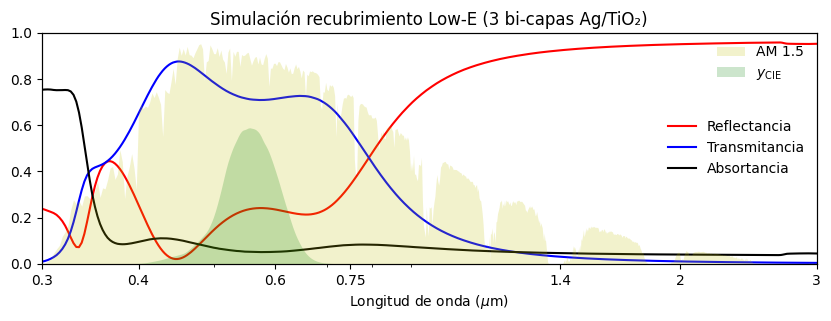

In [5]:
import empylib.nklib as nk
import empylib.waveoptics as wv
import empylib.ref_spectra as rf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# inicializamos índices de refracción y espectro
lam = np.linspace(0.3,3.0,1000)  # espectro de longitudes de onda (um)
n_air    = 1.0                   # índice de refracción del aire
n_glass  = nk.SiO2(lam)          # vidrio (SiO2)
n_silver = nk.silver(lam)        # plata
n_mox    = nk.TiO2(lam)          # óxido metálico (TiO2)
d_silver = 0.008                 # espesor capa de plata (um)
d_mox    = 0.030                 # espesor capa de TiO2 (um)

# construimos estructura multicapas (3 bi-capas Ag/TiO2)
n_layers = 3
n_lowE = [n_glass]
d_lowE = []
for i in range(n_layers):
    n_lowE.append(n_silver)
    n_lowE.append(n_mox)
    d_lowE.append(d_silver)
    d_lowE.append(d_mox)
n_lowE.append(n_air)

# calculamos reflectancia y transmitancia
R, T = wv.multilayer(lam, aoi=0, N_layers=n_lowE[1:-1], thickness=d_lowE,
                      N_above=n_lowE[0], N_below=n_lowE[-1])[:2]

# gráfico
fig, ax1 = plt.subplots(figsize=(10, 3))
ax1.plot(lam, R, '-r', label='Reflectancia')
ax1.plot(lam, T, '-b', label='Transmitancia')
ax1.plot(lam, 1 - R - T, '-k', label='Absortancia')
ax1.legend(frameon=False)

ax2 = ax1.twinx()
ax2.fill_between(lam, rf.AM15(lam)/1000, color='y', alpha=0.2, lw=0, label='AM 1.5')
ax2.fill_between(lam, rf.yCIE_lum(lam),  color='g', alpha=0.2, lw=0, label=r'$y_\mathrm{CIE}$')

ax1.set_xlabel(r'Longitud de onda ($\mu$m)')
ax1.set_xscale('log')
ax1.set_xticks([0.3, 0.4, 0.6, 0.75, 1.4, 2, 3])
ax1.set_xlim(lam[0], lam[-1])
ax1.set_ylim(0, 1)
ax2.set_ylim(bottom=0)
ax1.set_title('Simulación recubrimiento Low-E (3 bi-capas Ag/TiO₂)')
ax2.set_yticks([])
ax2.legend(frameon=False)
ax1.xaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.16g}'.format(y)))
plt.show()

**Desempeño del recubrimiento simulado**

Calculamos $T_\mathrm{lum}$ y $T_\mathrm{sol}$ integrando la transmitancia espectral con los pesos correspondientes:

In [6]:
# Transmitancia lumínica (visible, ponderada por y_CIE)
Tlum = np.trapz(rf.yCIE_lum(lam)*T, lam) / np.trapz(rf.yCIE_lum(lam), lam) * 100
print('Transmitancia lumínica: %.1f%%' % Tlum)

# Ganancia solar (solar, ponderada por AM1.5)
Tsolar = np.trapz(rf.AM15(lam)*T, lam) / np.trapz(rf.AM15(lam), lam) * 100
print('Ganancia solar (T_sol): %.1f%%' % Tsolar)

Transmitancia lumínica: 73.1%
Ganancia solar (T_sol): 46.6%


El recubrimiento simulado corresponde a una clasificación **73/47** ($T_\text{lum}$/G-solar): mantiene 73% de transmitancia visible pero reduce la ganancia solar al 47%.



En la industria, la notación T-vis/G-solar indica exactamente este balance. La siguiente tabla muestra datos técnicos reales del fabricante [IQ Glass](https://www.iqglassuk.com/products/solar-control-glass/s62761/):

| Clasificación | T-vis ($T_\mathrm{lum}$) | G-solar ($T_\mathrm{sol}$) | Reflectancia exterior |
|:-:|:-:|:-:|:-:|
| 70 / 37 | 70% | 36% | 11% |
| 70 / 41 | 70% | 41% | 11% |
| 62 / 34 | 62% | 34% | 15% |
| 51 / 28 | 51% | 28% | 12% |



>**Nota:** Reducir $T_\mathrm{sol}$ inevitablemente afecta $T_\mathrm{lum}$: existe un **trade-off** entre bloquear la ganancia solar y mantener la transparencia visual. Los vidrios más selectivos minimizan este trade-off.

#### Soft-coat low-E glass

El siguiente video muestra el proceso de fabricación de un vidrio Low-E con método *soft-coat*:

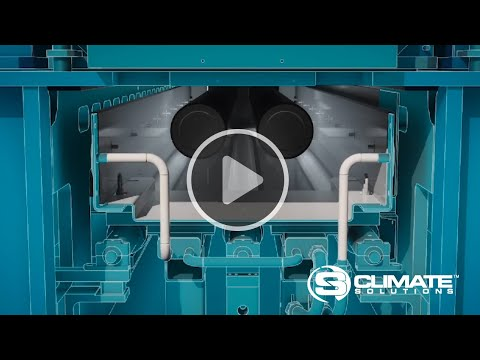

In [7]:
from IPython.display import YouTubeVideo
YouTubeVideo('p9H0ahGVRMM', width=700, height=400)

#### Filmes poliméricos

Los **filmes de control solar** son láminas delgadas —generalmente de polímero PET con recubrimientos metálicos o cerámicos— que se adhieren directamente sobre ventanas existentes. Son la solución de **retrofit** más accesible para edificios ya construidos.



Los filmes de control solar se clasifican mejor por su función óptica y constructiva. NREL (2024) identifica, entre otros, los siguientes tipos:

| Tipo | Mecanismo principal | Uso típico | Observaciones |
|:---:|:---:|:---:|:---:|
| **Reflectivo** | Refleja parte de la radiación solar; aspecto espejo | Alta reducción de ganancia solar y deslumbramiento | Puede aumentar reflectancia visible exterior |
| **Dual-reflective** | Capa exterior más reflectiva y cara interior más neutra | Control solar manteniendo mejor vista nocturna | Compromiso entre privacidad, estética y control solar |
| **Neutral** | Control solar con apariencia menos visible | Retrofit con menor impacto estético | La reducción de SHGC depende del producto |
| **Low-E film** | Reduce U-factor y mejora rechazo térmico | Climas templados o ventanas existentes con pérdidas térmicas | Puede ayudar más en invierno que un film solo reflectivo |
| **Espectralmente selectivo** | Bloquea bandas asociadas a calor solar sin penalizar tanto la luz visible | Fachadas donde se busca luz natural y bajo SHGC | Suele ser la opción más atractiva cuando se quiere conservar transparencia |
| **Cerámico** | Control solar sin capa metálica | Zonas costeras o donde importa corrosión/RF | Baja reflectancia visible y buena estabilidad |

Fuente: NREL *End-Use Savings Shapes Measure Documentation: Window Film* (2024).


Las ventajas de estos filmes de control solar incluyen:

- **Retrofit**: no requiere reemplazar las ventanas existentes → costo mucho menor que cambiar el sistema completo de ventana.
- Puede reducir SHGC y deslumbramiento en edificios existentes.
- Puede disminuir la exposición UV de mobiliario, textiles y superficies interiores.
- Es especialmente útil en climas con temporadas largas de enfriamiento; en climas fríos puede reducir también la ganancia solar útil de invierno.


Por otro lado, las limitaciones incluyen:

- **Vida útil más corta** que un Low-E integrado en vidrio doble (ver tabla).
- Degradación por UV, humedad y ciclos térmicos; riesgo de delaminación y burbujas.
- Un film absorbente puede calentar el vidrio y causar **stress térmico** (riesgo de fractura en vidrios con marco metálico).
- En climas con invierno frío, reducir $T_\mathrm{sol}$ también reduce la **ganancia solar útil en invierno**.
- Instalación profesional recomendada para maximizar durabilidad.



#### Durabilidad y condiciones de uso

La documentación DOE/NREL no entrega una vida útil universal para todos los filmes o coatings, porque depende del producto, instalación y exposición. Para seleccionar una solución conviene distinguir el mecanismo de degradación dominante:

| Tecnología | Factor crítico | Comentario de diseño |
|:---:|:---:|:---:|
| Film interior | Temperatura del vidrio, humedad, adhesivo, limpieza | Menor exposición que un film exterior, pero puede elevar temperatura del vidrio |
| Film exterior | UV, lluvia, abrasión, sales, limpieza | Puede mejorar desempeño solar en ciertos casos, pero exige mayor mantención |
| Low-E soft-coat en IGU | Sellado perimetral y protección del coating | El coating debe quedar protegido dentro de la cámara |
| Low-E hard-coat | Resistencia superficial y compatibilidad con instalación | Más robusto a manipulación, con menor selectividad que soft-coat |
| Electrocrómico | ciclos de switching, uniformidad, sellado, control | DOE menciona normas ASTM de envejecimiento acelerado para validar durabilidad |

Fuentes: NREL *Window Film* (2024); DOE EC Window Report (2022/2023); DOE Energy Saver.


### Ventanas inteligentes

Los recubrimientos Low-E y los filmes de control solar tienen propiedades fijas: funcionan igual en verano que en invierno. Las **ventanas inteligentes** (*switchable glazing*) van más allá: pueden cambiar sus propiedades ópticas en respuesta a un estímulo, adaptándose a las condiciones del momento.

Dependiendo de la aplicación, una ventana inteligente puede ser diseñada para regular el paso de la radiación solar visible, UV o del infrarrojo cercano (NIR).

Distinguimos dos tipos: 
- **termocrómicas** responden a cambios de temperatura
- **eléctrocrómicas** responden a cambios en el potencial eléctrico (voltaje).

<img src="./images/g-smart-window-types-alt.jpg" width="500" align=center>

<center><small><b>Figura 10.</b> Tipos de ventanas inteligentes y su principio de operación (<a href="https://www.energystar.gov">ENERGY STAR</a>).</small></center>

#### Materiales electrocrómicos

Entre las ventanas inteligentes, los **electrocrómicos** (EC) son actualmente la tecnología con mayor penetración comercial en edificaciones.


Una ventana electrocrómicas consiste en un vidrio doble con una estructura multicapa activa:

$$\mathrm{vidrio} \;|\; \underbrace{\mathrm{ITO}}_{\text{electrodo}} \;|\; \underbrace{\mathrm{WO_3}}_{\text{capa EC}} \;|\; \underbrace{\text{conductor iónico}}_{\text{electrolito}} \;|\; \underbrace{\mathrm{NiO}}_{\text{contraelectrodo}} \;|\; \underbrace{\mathrm{ITO}}_{\text{electrodo}} \;|\; \mathrm{vidrio}$$



Al aplicar un voltaje de **1–5 V DC**, iones $\text{Li}^+$ en el electrolito se intercalan en la capa de $\text{WO}_3$, cambiando su estado de oxidación:

\begin{equation*}
\mathrm{WO_3~(transparente)} + x\,\mathrm{Li}^+ + x\,e^- \;\rightleftharpoons\; \mathrm{Li}_x\mathrm{WO_3~(azulado, absorbente)}
\end{equation*}


El proceso es **reversible** y el estado tintado puede mantenerse con bajo consumo eléctrico. Como referencia de diseño, NREL (2022) plantea para ventanas dinámicas un objetivo de baja potencia de operación: menor que 3 W/m², o menor que 72 Wh/m² por día, con alimentación de bajo voltaje (3–5 V DC).


#### Capacidad de modulación

Una ventana EC no tiene un único valor de desempeño: varía entre un estado claro y uno tintado. Como referencia de diseño:

- NREL (2022) usa para ventanas dinámicas de alto desempeño un rango operativo de SHGC de aproximadamente **0.05–0.65**.
- IEA (*Innovation Gaps: Buildings*) identifica como prioridad desarrollar vidrios dinámicos con SHGC variable de aproximadamente **0.08–0.65**.
- Revisiones recientes de ventanas inteligentes señalan que, para aplicaciones reales en edificios, son deseables alta transmitancia visible en estado claro, contraste claro/oscuro suficiente, switching de minutos y estabilidad de largo plazo.

Esto permite controlar tanto el **deslumbramiento** como la **ganancia solar**, pero siempre existe un balance con luz natural, confort visual, color residual y estrategia de control.


#### Beneficios en edificaciones

1. **Confort visual:** elimina el deslumbramiento sin necesidad de persianas mecánicas.
2. **Reducción de carga de enfriamiento:** SHGC controlable según la hora y el clima.
3. **Gestión de demanda eléctrica:** reducir ganancia solar en horas de pico eléctrico puede aliviar la red.
4. **Sin piezas móviles:** no requiere mantenimiento mecánico.
5. **Integración con automatización:** puede programarse según orientación, hora del día, sensores de irradiación o comandos del ocupante.



Los beneficios energéticos medidos dependen fuertemente del edificio y del algoritmo de control. 
- El DOE EC Window Report resume casos reales: en un caso de sala de reuniones se estimaron **39–48%** de ahorros combinados de iluminación y HVAC
- En un edificio GSA en Portland se reportó **36%** menos demanda anual de iluminación, aunque el HVAC anual aumentó levemente en horario laboral
- en estudios de vidrios cromogénicos controlados se estiman reducciones de **10–20%** en energía de HVAC+iluminación de zonas perimetrales y **20–30%** en demanda eléctrica peak. 


#### Limitaciones reales

| Limitación | Evidencia / criterio de diseño |
|:---:|:---:|
| Costo | DOE identifica el costo como una barrera importante de adopción; NREL formula metas de reducción de costo para hacer viables ventanas dinámicas hacia 2030 |
| Velocidad de switching | DOE señala tiempos de cambio relativamente largos; NREL plantea como meta menos de 3 min para ventanas grandes, pero muchas tecnologías reales son más lentas |
| Color residual | DOE menciona preferencia de usuarios por tonos neutros y apariencia uniforme |
| Control | El ahorro depende del algoritmo: minimizar HVAC, iluminación y deslumbramiento son objetivos que pueden entrar en conflicto |
| Durabilidad | Existen ensayos ASTM de envejecimiento acelerado; revisiones técnicas consideran deseable sostener desempeño por 20–30 años o decenas de miles de ciclos, pero eso no equivale a garantía universal |
| Instalación | Requiere integración eléctrica, sensores o BMS cuando se busca control automático |


>**Criterio ingenieril:** el costo de los electrocrómicos se justifica principalmente en fachadas vidriadas de edificios de oficinas en climas cálidos, donde el confort visual y la reducción de carga de enfriamiento generan retorno de inversión. En viviendas con presupuesto limitado, un Low-E de alta calidad en doble vidrio es más costo-efectivo.

#### Materiales termocrómicos

Las ventanas **termocrómicas** responden a cambios de temperatura sin necesidad de electricidad. 

<img src="./images/smart_windows_closing.jpg" width="800" align=center>

<center><small><b>Figura 11.</b> Operación estacional de ventanas termocrómicas: bloqueo del NIR en verano y captación en invierno (<a href="https://onlinelibrary.wiley.com/doi/full/10.1002/aenm.201602209">Khandelwal, H. et al., Adv. Energy Mater. 7(14), 2017</a>).</small></center>

El material más estudiado es el **dióxido de vanadio (VO$_2$)**. Este material exhibe una **transición de fase aislante-conductor** que altera drásticamente sus propiedades ópticas en el NIR:
- **Por debajo de $T_\mathrm{trans}$** (fase aislante): alta transmitancia NIR → permite ganancia solar.
- **Por encima de $T_\mathrm{trans}$** (fase conductora): alta reflectancia NIR → bloquea ganancia solar.


<img src="./images/vanadium_dioxide.png" width="800" align=center>

<center><small><b>Figura 12.</b> (izquierda) Transición de fase en VO₂ y su efecto en la reflectancia espectral. (derecha) Cambio en la estructura cristalina del VO₂ de monoclínico (M) a rutilo (R) inducida por cambio de fase y sus implicaciones en la conductividad eléctrica (<a href="https://doi.org/10.1039/C3CS35508J">Wu, C et al., Chem. Soc. Rev. 42(12), 2013: 5157–5183</a>).</small></center>

La temperatura de transición intrínseca del VO$_2$ es cercana a **68–70°C**, demasiado alta para confort en edificios. Puede reducirse hacia rangos cercanos a temperatura ambiente mediante dopaje (por ejemplo W o Mo), aunque esto puede afectar transmitancia visible, histéresis, durabilidad o modulación solar.


Las ventanas $\text{VO}_2$ se fabrican como una capa delgada depositada sobre vidrio, o como partículas dispersas en un polímero transparente:

<img src="./images/vo2_smart_windows.png" width="700" align=center>

<center><small><b>Figura 13.</b> Diseños a escala laboratorio de recubrimientos termocrómicos de VO₂ y modulación de transmitancia medida en espectrofotómetro UV-vis-NIR.</small></center>

El desempeño se cuantifica mediante:
- $T_\mathrm{lum}$: debe ser alto en ambas fases para ser útil visualmente.
- $\Delta T_\mathrm{sol} = T_\mathrm{sol}^\mathrm{frío} - T_\mathrm{sol}^\mathrm{caliente}$: modulación de ganancia solar. En prototipos de ventanas inteligentes, una modulación de varios puntos porcentuales ya es relevante; valores sobre ~10% son atractivos solo si se mantienen buena transparencia, color aceptable y durabilidad.


Además del VO$_2$ existen otros materiales estudiados en ventanas inteligentes, tales como los hidrogeles y las perovskitas.

<img src="./images/smart-window_table.png" width="600" align= center>

<center><small><b>Figura 14.</b> Comparación de transmitancia lumínica (Tlum) y modulación solar (DTsol) para distintos materiales de ventanas inteligentes.</small></center>

El mercado de ventanas inteligentes para edificaciones está dominado por electrocrómicos. Los recubrimientos termocrómicos de VO$_2$ siguen más cerca de I+D o nichos específicos porque muchos prototipos sacrifican una o más variables críticas:

- Temperatura de transición difícil de ubicar exactamente en el rango útil.
- Transmitancia visible y color no siempre compatibles con confort visual.
- Histéresis, oxidación y estabilidad de largo plazo aún desafiantes.


### Analisis comparativos de tecnologías

| Tecnología | Estímulo | ¿Eléctrica? | Espectro modulado | Madurez comercial | Ventajas | Limitaciones |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **Low-E** (referencia) | — (fijo) | No | NIR solar + IR térmico | Muy madura | Bajo costo relativo; sin control activo | No modulable |
| **Film control solar** | — (fijo) | No | NIR + visible, según film | Madura | Retrofit; evita reemplazo completo | Desempeño y durabilidad dependen del producto/base |
| **Electrocrómico** | Voltaje DC | Sí | Visible + NIR | Comercial disponible | Control preciso; posible integración con BMS; reduce deslumbramiento | Costo; switching; control necesario |
| **Termocróm. VO₂** | Temperatura | No | NIR solar | I+D / nicho | Pasivo; sin cableado | T de transición, color, $T_\mathrm{lum}$ y durabilidad |

Fuentes: DOE EC Window Report (2022/2023); LBNL EC Fact Sheet; NREL *Pathway to Zero Energy Windows* (2022); Wu et al. (2023).


La tabla resume **rangos orientativos** para análisis de curso. Para especificación de proyecto se deben usar fichas NFRC/IGDB o datos del fabricante, porque $T_\mathrm{lum}$, SHGC, U-value y emisividad dependen del espesor, cámara de aire, gas, marco y coating.

| Tecnología | $T_\mathrm{lum}$ / VLT | $T_\mathrm{sol}$ / SHGC | U-value [W/m²K] | $\varepsilon$ IR |
|:---:|:---:|:---:|:---:|:---:|
| Vidrio simple claro | ~80–90% | ~0.75–0.86 | ~5.6–6.0 | ~0.84 |
| Vidrio doble claro (sin coating) | ~70–80% | ~0.65–0.75 | ~2.7–3.0 | ~0.84 |
| Low-E soft-coat (IGU) | ~60–75% | ~0.25–0.45 | ~1.0–1.8 | ~0.02–0.10 |
| Film de control solar | depende del producto | NREL reporta reducciones de SHGC de 17–71% respecto al vidrio base | mejora de U-factor 0–22% | depende del film |
| Vidrio dinámico / electrocrómico | variable claro–oscuro | NREL/IEA usan rangos dinámicos objetivo ~0.05–0.65 | similar al IGU base | depende del stack |

Fuentes: NREL *Pathway to Zero Energy Windows* (2022); NREL *Window Film* (2024); IEA *Innovation Gaps: Buildings – Advanced windows*; DOE EC Window Report (2022/2023).


## Recubrimientos de enfriamiento radiativo pasivo

Las tecnologías de enfriamiento radiativo buscan que las superficies de un edificio **emitan más calor del que reciben**, reduciendo la temperatura superficial y aliviando la carga de los sistemas de aire acondicionado.



### El balance radiativo de una superficie

Una superficie en el exterior intercambia energía de las siguientes formas:

\begin{equation*}
P_\mathrm{neto} = \underbrace{P_\mathrm{emit}}_{\text{emisión IR}} - \underbrace{P_\mathrm{atm}}_{\text{recibido de atm.}} - \underbrace{\alpha_\mathrm{sol}\cdot G_\mathrm{solar}}_{\text{absorbido solar}} - \underbrace{P_\mathrm{conv}}_{\text{ganancia convectiva}}
\end{equation*}



Para que la superficie se enfríe ($P_\mathrm{neto} > 0$), se necesita:
1. Alta emisividad en la ventana atmosférica (8–13 μm) para maximizar $P_\mathrm{emit}$.
2. Alta reflectancia solar para minimizar $\alpha_\mathrm{sol} \cdot G_\mathrm{solar}$.



El fenómeno también depende de las condiciones externas, cielo despejado, baja humedad, baja temperatura de la atmósfera, y factor de vista al cielo. En condiciones desfavorables, el efecto puede ser nulo.

### Solar Refractive Index (SRI)

ASTM E1980 define SRI comparando la temperatura superficial de un material con un blanco estándar y un negro estándar bajo condiciones normalizadas. 
- El blanco estándar tiene reflectancia solar 0.80, emisividad térmica 0.90 y SRI = 100
- El negro estándar tiene reflectancia solar 0.05, emisividad 0.90 y SRI = 0.

<img src="./images/SRI_illustration.png" width="550" align=center>

<center><small><b>Figura 15.</b> Cargas térmicas consideradas en el cálculo del SRI (Understanding the solar reflectance index, Cool Roof Rating Council, 2024)</small></center>

### Primera generación: cool roofs

Los **cool roofs** (techos fríos) son la tecnología más madura del enfriamiento radiativo. El principio es simple: aumentar la reflectancia solar del techo para reducir la energía absorbida.


Un buen cool roof tiene SRI > 78

**Impacto medido:**
- Reducción de temperatura superficial: DOE Energy Saver reporta que, bajo las mismas condiciones, un techo reflectivo puede mantenerse más de **50°F (28°C)** más frío que un techo convencional.
- Reducción de demanda peak de enfriamiento: EPA reporta **11–27%** en edificios residenciales acondicionados.
- Reducción de temperatura interior máxima: EPA reporta **1.2–3.3°C** en viviendas sin aire acondicionado.
- Reducción del efecto isla de calor urbana cuando se implementa a escala.


**Estado comercial:** tecnología completamente madura. Pinturas reflectantes blancas, membranas TPO y tejas reflectantes están disponibles en el mercado estándar de construcción.

### Segunda generación: enfriamiento radiativo diurno pasivo (PDRC)

Los materiales de **enfriamiento radiativo diurno pasivo** (*Passive Daytime Radiative Cooling*, PDRC) van más allá del cool roof convencional:

1. Alta reflectancia solar ($\rho_\mathrm{sol} > 0.90$–$0.97$): minimiza $\alpha_\mathrm{sol} \cdot G_\mathrm{solar}$.
2. Alta emisividad selectiva en la ventana atmosférica (8–13 μm): maximiza $P_\mathrm{emit}$ hacia el espacio.

Esto equivale a SRI > 100

Cuando estas condiciones se cumplen, la potencia de enfriamiento neta puede ser positiva incluso bajo irradiación solar directa:

\begin{equation*}
P_\mathrm{cool} = P_\mathrm{emit}(8\text{–}13\,\mu\mathrm{m}) - P_\mathrm{atm}(8\text{–}13\,\mu\mathrm{m}) - \alpha_\mathrm{sol}\cdot G_\mathrm{solar} - P_\mathrm{conv} > 0
\end{equation*}



**El universo actúa como sumidero térmico:** el material puede alcanzar temperaturas **por debajo de la temperatura ambiente** a plena luz del día.

#### PDRC en la naturaleza: las hormigas de plata del Sahara



Un ejemplo natural de PDRC es la *hormiga plateada del Sahara* (*Cataglyphis bombycina*). 

<img src="./images/silver_ants.png" width="700" align=center>

<center><small><b>Figura 16.</b> Hormiga de plata del Sahara (<i>Cataglyphis bombycina</i>): su coloración plateada resulta de las propiedades ópticas selectivas de sus pelos.</small></center>

Sus pelos crean efectos de scattering para longitudes de onda corta, aumentando selectivamente la reflectancia en el visible, lo que les da el característico color plateado.

<img src="./images/silver_ants_scattering.png" width="700" align=center>

<center><small><b>Figura 17.</b> Mecanismo de scattering en los pelos de la hormiga de plata: alta reflectancia en el espectro visible y emisión eficiente en el IR térmico.</small></center>

#### Materiales PDRC artificiales

Artificialmente, el fenómeno se reproduce con **polímeros porosos**. La porosidad —inducida mediante separación de fases— crea microestructuras que dispersan la radiación solar (alta reflectancia en UV-vis-NIR) y emiten eficientemente en el IR térmico.



<img src="./images/radiative_cooling_film.png" width="900" align=center>

<center><small><b>Figura 18.</b> Film polimérico poroso P(VdF-HFP) para enfriamiento radiativo pasivo diurno: alta reflectancia solar y emisividad térmica elevada en la ventana atmosférica.</small></center>

El estudio de [Mandal et al. (Science, 2018)](https://doi.org/10.1126/science.aat9513) demuestra un recubrimiento polimérico poroso con $\rho_\mathrm{sol} > 0.96$ y emisividad térmica hemisférica cercana a 0.97, logrando enfriamiento subambiente de alrededor de 6°C bajo radiación solar directa en sus ensayos. Esta es la fuente correcta del DOI 10.1126/science.aat9513; no corresponde a Zhai et al.

Los materiales PDRC se pueden formular como **pinturas, láminas adhesivas, ropa y materiales estructurales**:

<img src="./images/radiative_cooling_format.png" width="900" align=center>

<center><small><b>Figura 19.</b> Formatos de aplicación de materiales PDRC: pinturas, láminas adhesivas, ropa y materiales estructurales.</small></center>

**Estado comercial:** tecnología emergente. Ya existen empresas y pilotos comerciales de enfriamiento radiativo, pero el desempeño real depende del clima, factor de vista al cielo, ensuciamiento, integración constructiva y costo. [SkyCool Systems](https://www.skycoolsystems.com/) es un ejemplo de aplicación comercial en paneles de enfriamiento radiativo para usos industriales:


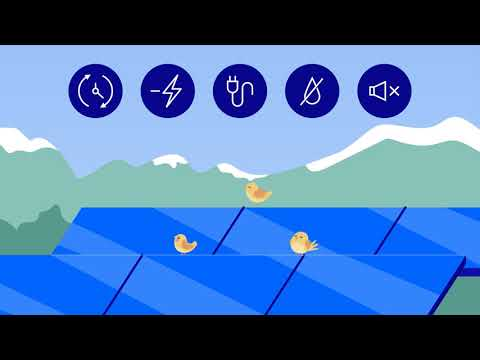

In [8]:
from IPython.display import YouTubeVideo
YouTubeVideo('CMaZfuInd9c', width=700, height=400)

## Limitaciones reales y selección climática

No existe tecnología universal. La selección depende del clima local, el tipo de edificio y el balance anual de cargas.



Para Low-E y filmes de control solar
- En climas **cálidos sin invierno frío**: priorizar bajo $T_\mathrm{sol}$ (SHGC). La pérdida de ganancia solar en invierno tiene poca importancia.
- En climas **con invierno frío**: buscar balance entre bajo SHGC (verano) y bajo U-value (invierno). Un Low-E soft-coat en doble vidrio es la solución más versátil.



Para electrocrómicos
- La inversión se justifica principalmente en **fachadas vidriadas de oficinas** en climas cálidos, donde el confort visual y la reducción de pico de demanda son críticos.
- En viviendas con presupuesto limitado, un Low-E de calidad es más costo-efectivo.



Para enfriamiento radiativo (cool roofs y PDRC)

Las siguientes condiciones **reducen o anulan** el efecto de enfriamiento radiativo:

1. **Alta humedad relativa**: el vapor de agua absorbe radiación dentro y alrededor de la ventana atmosférica 8–13 μm → menor enfriamiento efectivo.
2. **Alta nubosidad**: las nubes actúan como cuerpos emisores a temperatura cercana a la ambiente → reducen la vista radiativa al cielo frío.
3. **Contaminación y smog**: absorción y dispersión adicional en el IR atmosférico.
4. **Fachadas verticales**: factor de vista al cielo bajo; el beneficio es marginal vs techo horizontal.
5. **Polvo y ensuciamiento**: degradan la reflectancia solar → mantenimiento periódico necesario.
6. **Entornos urbanos densos**: baja visión de cielo; radiación IR de edificios vecinos calienta la superficie.


### Caso Chile: norte seco vs zona central vs sur húmedo

En Chile, la diversidad climática —desde el desierto de Atacama hasta la Patagonia— implica que las soluciones no son universales. Los valores de las tablas siguientes son **órdenes de magnitud para discusión de diseño**, basados en datos de irradiación usados en la Unidad 7/Explorador Solar y en resúmenes climatológicos de la Dirección Meteorológica de Chile; para diseño ejecutivo se debe usar un archivo climático local o mediciones del sitio.


Comparemos tres zonas representativas usando los criterios de la sección anterior:

#### Antofagasta / Copiapó — Norte árido



- Ventana atmosférica: muy favorable en interior seco y despejado → **PDRC muy efectivo**.
- En costa con camanchaca o nubosidad baja, el desempeño PDRC debe evaluarse con datos locales.
- Radiación solar altísima y carga de enfriamiento alta → **Low-E y filmes altamente recomendados**.
- Cool roofs: **muy efectivos** → reducciones de temperatura superficial del orden de 25–30°C son coherentes con DOE para techos reflectivos vs convencionales.
- Electrocrómicos: justificados en edificios comerciales o de alta demanda de enfriamiento.
- Inviernos benignos → la pérdida de ganancia solar suele ser menos crítica que en climas de calefacción dominante.


| Variable | Valor típico / criterio |
|:---:|:---:|
| Irradiación solar (GHI) | ~2 400–2 600 kWh/m²/año en zonas de alto recurso (datos Unidad 7 / Explorador Solar) |
| Humedad relativa | Baja en interior árido; la costa de Antofagasta puede tener HR más alta por camanchaca |
| Nubosidad anual | Muy baja en interior; mayor presencia de nubosidad baja en costa |
| Contaminación | Baja a moderada, según ciudad y cercanía industrial |


**Tecnología prioritaria:** Low-E de bajo SHGC + PDRC en techos.

#### Santiago — Clima mediterráneo



- PDRC: **efectivo en verano** (cielo claro, baja HR); **limitado en invierno** (nubosidad, smog, mayor HR).
- Materiales adaptativos (TARC): serían ideales para el ciclo verano/invierno de Santiago.
- Low-E con balance SHGC/U-value: **solución más robusta** para viviendas.
- Cool roofs: efectivos en verano.
- Electrocrómicos: justificados en edificios de oficinas con fachada vidriada (Providencia, Las Condes).

| Variable | Valor típico / criterio |
|:---:|:---:|
| Irradiación solar (GHI) | ~1 700–1 900 kWh/m²/año |
| Humedad relativa media | Moderada; mayor en invierno que en verano |
| Nubosidad anual | Veranos soleados; inviernos más nublados |
| Contaminación | Alta en episodios invernales de estabilidad atmosférica |


**Tecnología prioritaria:** Low-E de balance (SHGC ~0.35–0.45, U bajo según presupuesto y marco) + cool roof en techos planos industriales o edificios.


#### Puerto Montt / Valdivia — Sur lluvioso



- PDRC: **muy limitado** por humedad y nubosidad → el efecto de enfriamiento es mínimo.
- Cool roofs: beneficio reducido; la **calefacción domina** sobre el enfriamiento.
- Low-E: relevante principalmente para **reducir pérdidas térmicas** (bajo U-value, no bajo SHGC).
- Electrocrómicos y filmes: poca justificación económica dado el bajo potencial de enfriamiento.

| Variable | Valor típico / criterio |
|:---:|:---:|
| Irradiación solar (GHI) | ~1 000–1 200 kWh/m²/año |
| Humedad relativa media | Alta |
| Nubosidad anual | Alta durante gran parte del año |
| Precipitación | Alta, frecuentemente del orden de miles de mm/año según localidad |


**Tecnología prioritaria:** doble vidrio + Low-E hard-coat (bajo U-value) para retención de calor; masa térmica alta en muros para suavizar fluctuaciones.

En síntesis, **no hay una tecnología universal**. En el norte árido, la prioridad es bloquear la ganancia solar y aprovechar el enfriamiento radiativo. En el sur húmedo, la prioridad es conservar el calor. Santiago requiere un balance estacional que los materiales adaptativos podrían resolver en el futuro.

### Guía de selección de tecnología

| Escenario | Tecnología recomendada | Alternativa | Razón principal |
|:---:|:---:|:---:|:---:|
| **Edificio nuevo en clima cálido seco** | Low-E soft-coat (bajo SHGC) + Cool roof | Electrocrómico en fachadas vidriadas | Máxima reducción de carga de enfriamiento; robusto y sin mantenimiento |
| **Retrofit barato** | Film espectralmente selectivo (interior) | — | Bajo costo; no requiere reemplazar ventanas |
| **Fachada vidriada con deslumbramiento** | Electrocrómico | Film (sin control dinámico) | Control preciso de $T_\mathrm{lum}$ y SHGC; elimina necesidad de persianas |
| **Vivienda con invierno frío y verano caluroso** | Low-E balance + doble vidrio (U bajo) | Film + masa térmica | Reduce pérdidas en invierno y ganancia en verano |
| **Techo industrial en zona seca** | PDRC (pintura o lámina) sobre cool roof | Cool roof blanco simple | Máximo efecto radiativo; bajo costo de pintura |
| **Zona húmeda/nublada** | Masa térmica + Low-E (U-value bajo) | Cool roof (beneficio parcial) | PDRC tiene impacto limitado; priorizar aislación |

### Estado de madurez de las tecnologías

| Tecnología | Estado actual | Observación |
|:---:|:---:|:---:|
| Cool roofs | Completamente madura | Disponible en el mercado estándar de construcción |
| Low-E (hard-coat y soft-coat) | Completamente madura | Estándar en ventanas de alto desempeño |
| Filmes de control solar | Madura | Ampliamente disponibles; desempeño depende del vidrio base y del producto |
| Electrocrómicos | Comercial disponible | Barreras de costo y control; ideal para edificios con fachadas vidriadas y alto valor de confort visual |
| Termocrómicos VO₂ | I+D / nicho | Sin solución comercial robusta y masiva aún |
| PDRC (pinturas y láminas) | Emergente / primeras aplicaciones comerciales | Prometedor en climas secos y despejados; sensible a humedad, nubosidad y ensuciamiento |
| Materiales adaptativos (TARC) | I+D | Muy prometedores para evitar sobreenfriamiento, pero aún no comerciales |


## Referencias

1. IEA. *Energy Efficiency 2025 – Buildings Chapter.* International Energy Agency, 2025. [https://www.iea.org/reports/energy-efficiency-2025/buildings](https://www.iea.org/reports/energy-efficiency-2025/buildings)

2. IEA. *Buildings.* International Energy Agency, sector tracking page. [https://www.iea.org/reports/buildings](https://www.iea.org/reports/buildings)

3. IEA. *The Future of Cooling.* International Energy Agency, 2018. [https://www.iea.org/reports/the-future-of-cooling](https://www.iea.org/reports/the-future-of-cooling)

4. IEA. *Innovation Gaps: Buildings – Advanced Windows.* [https://www.iea.org/reports/innovation-gaps/buildings](https://www.iea.org/reports/innovation-gaps/buildings)

5. U.S. DOE. *Better Windows, Better Outcomes: How Electrochromics Improve Health, Productivity, and Efficiency.* Building Technologies Office, 2022/2023. [https://www.energy.gov/sites/default/files/2023-12/bto-electrochromic-window-report-121123.pdf](https://www.energy.gov/sites/default/files/2023-12/bto-electrochromic-window-report-121123.pdf)

6. LBNL Windows Group. *Electrochromic Windows Fact Sheet.* Lawrence Berkeley National Laboratory. [https://windows.lbl.gov/sites/default/files/EC-Windows-FactSheet_v9.pdf](https://windows.lbl.gov/sites/default/files/EC-Windows-FactSheet_v9.pdf)

7. Kim, J.; CaraDonna, C.; Parker, A. *End-Use Savings Shapes Measure Documentation: Window Film.* NREL/TP-5500-86554, 2024. [https://doi.org/10.2172/2447836](https://doi.org/10.2172/2447836)

8. U.S. DOE / NREL. *Pathway to Zero Energy Windows: Advancing Technologies and Market Adoption.* 2022. [https://docs.nrel.gov/docs/fy22osti/80171.pdf](https://docs.nrel.gov/docs/fy22osti/80171.pdf)

9. U.S. DOE Energy Saver. *Energy Efficient Window Coverings – Window Films.* [https://www.energy.gov/energysaver/energy-efficient-window-coverings](https://www.energy.gov/energysaver/energy-efficient-window-coverings)

10. U.S. EPA. *Using Cool Roofs to Reduce Heat Islands.* [https://www.epa.gov/heatislands/using-cool-roofs-reduce-heat-islands](https://www.epa.gov/heatislands/using-cool-roofs-reduce-heat-islands)

11. U.S. DOE Energy Saver. *Cool Roofs.* [https://www.energy.gov/energysaver/cool-roofs](https://www.energy.gov/energysaver/cool-roofs)

12. NREL. *Reference Air Mass 1.5 Spectra / ASTM G173.* [https://www.nrel.gov/grid/solar-resource/spectra-am1.5](https://www.nrel.gov/grid/solar-resource/spectra-am1.5)

13. Wu, S. et al. *Applications of thermochromic and electrochromic smart windows: Materials to buildings.* **Cell Reports Physical Science** 4, 101370, 2023. DOI: [10.1016/j.xcrp.2023.101370](https://doi.org/10.1016/j.xcrp.2023.101370)

14. Wang, X.; Narayan, S. *Thermochromic Materials for Smart Windows: A State-of-Art Review.* **Frontiers in Energy Research** 9, 800382, 2021. DOI: [10.3389/fenrg.2021.800382](https://doi.org/10.3389/fenrg.2021.800382)

15. Mandal, J. et al. *Hierarchically porous polymer coatings for highly efficient passive daytime radiative cooling.* **Science** 362(6412), 315–319, 2018. DOI: [10.1126/science.aat9513](https://doi.org/10.1126/science.aat9513)

16. Tang, K. et al. *Temperature-adaptive radiative coating for all-season household thermal regulation.* **Science** 374(6574), 1504–1509, 2021. DOI: [10.1126/science.abf7136](https://doi.org/10.1126/science.abf7136)

17. Ministerio de Energía de Chile. *Explorador Solar.* [https://solar.minenergia.cl](https://solar.minenergia.cl)

18. Dirección Meteorológica de Chile. *Servicios climáticos y resúmenes climatológicos.* [https://climatologia.meteochile.gob.cl](https://climatologia.meteochile.gob.cl)

19. Kalogirou, S.A. *Chapter 6: Solar space heating and cooling.* En **Solar Energy Engineering: Processes and Systems**, 2nd Ed., Academic Press, 2014.
